
# Treasury PCA Butterfly and Relative Value

This notebook turns a simple PCA butterfly exercise into a cleaner rates
relative-value research project.  It separates factor discovery, hedge
construction, signal design, walk-forward testing, and bond implementation.



## Executive takeaways

- PCA should be run on yield changes, not yield levels.  Correlation PCA is good
  for factor interpretation, while covariance PCA is better for hedge weights in
  yield-bp P&L units.
- A static full-sample butterfly is useful for explaining the idea but is not a
  valid backtest.  The walk-forward version estimates PCA weights only from past
  data.
- The signal has weak standalone performance once costs, regimes, and rolling
  weights are included.  The strongest part of the project is the framework:
  it shows how to turn a clean factor residual into a tradable relative-value
  hypothesis and then attack the implementation gap.


In [1]:

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

from treasury_pca_butterfly import (
    adf_summary,
    backtest_mean_reversion,
    compute_spread,
    fit_pca,
    half_life_days,
    load_gsw_yields,
    load_treasury_panel,
    monthly_rolling_weights,
    performance_stats,
    pick_nearest_bonds,
    regime,
    rolling_zscore,
    solve_butterfly_weights,
    spread_from_weight_history,
)

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")


Matplotlib is building the font cache; this may take a moment.



## 1. Data

The GSW file provides fixed-maturity yields.  The Treasury panel is used later
to show how much slippage appears when the signal is mapped to actual bonds.
Raw workbooks are ignored by git.


In [2]:

yields_bp = load_gsw_yields(PROJECT_ROOT)
panel = load_treasury_panel(PROJECT_ROOT)

overview = pd.DataFrame(
    {
        "rows": [len(yields_bp), len(panel)],
        "start": [yields_bp.index.min().date(), panel["caldt"].min().date()],
        "end": [yields_bp.index.max().date(), panel["caldt"].max().date()],
        "columns": [len(yields_bp.columns), len(panel.columns)],
    },
    index=["GSW fixed-maturity yields", "Treasury bond panel"],
)
display(overview)


,rows,start,end,columns
GSW fixed-maturity yields,16097,1961-06-14,2025-12-26,30
Treasury bond panel,204868,2022-01-03,2025-12-31,14



## 2. Factor discovery

I estimate PCA on daily yield changes.  The table compares correlation PCA,
which equal-weights maturities for interpretation, and covariance PCA, which
keeps yield-bp risk units for hedge construction.


,correlation,covariance
PC1,0.8809,0.8812
PC2,0.0867,0.0869
PC3,0.0232,0.0228


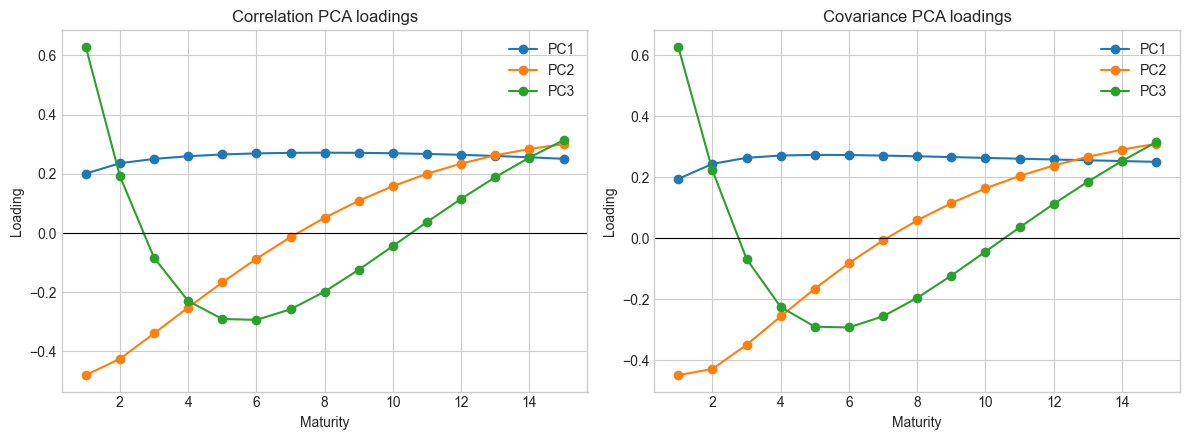

In [3]:

corr_fit = fit_pca(yields_bp, method="correlation")
cov_fit = fit_pca(yields_bp, method="covariance")

factor_table = pd.concat(
    {
        "correlation": corr_fit.explained_variance,
        "covariance": cov_fit.explained_variance,
    },
    axis=1,
)
display(factor_table)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=False)
corr_fit.loadings.plot(ax=axes[0], marker="o", title="Correlation PCA loadings")
cov_fit.loadings.plot(ax=axes[1], marker="o", title="Covariance PCA loadings")
for ax in axes:
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xlabel("Maturity")
    ax.set_ylabel("Loading")
plt.tight_layout()
plt.show()



## 3. Static butterfly construction

The explanatory butterfly shorts the 5Y belly (`w_5Y = -1`) and solves for 2Y
and 10Y weights that neutralize PC1 and PC2 exposure under covariance PCA.


,weight
2,0.5777
5,-1.0000
10,0.5026


,factor_exposure
PC1,0.0000
PC2,0.0000
PC3,0.3963


,static_spread_diagnostics
adf_stat,-2.3160
pvalue,0.1669
used_lag,0.0000
nobs,"16,096.0000"
half_life_days,"1,222.0722"
mean_bp,0.1284
std_bp,102.3740


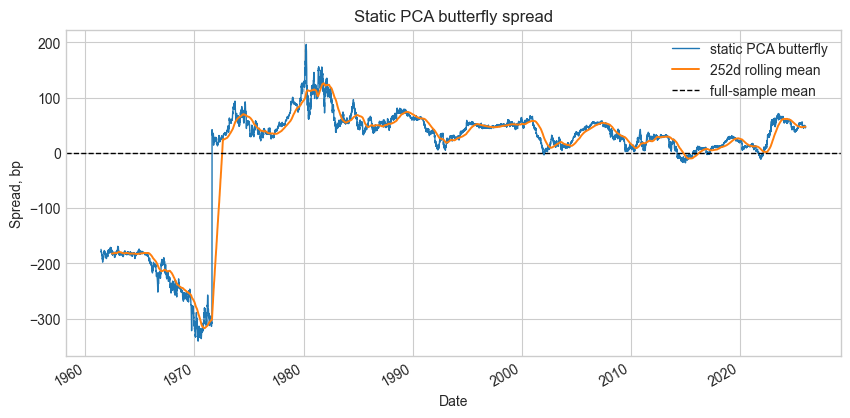

In [4]:

static_weights = solve_butterfly_weights(cov_fit.loadings)
static_exposures = cov_fit.loadings.loc[static_weights.index, ["PC1", "PC2", "PC3"]].mul(static_weights, axis=0).sum()
static_spread = compute_spread(yields_bp, static_weights)

display(static_weights.to_frame())
display(static_exposures.to_frame("factor_exposure"))

diagnostics = {
    **adf_summary(static_spread),
    "half_life_days": half_life_days(static_spread),
    "mean_bp": static_spread.mean(),
    "std_bp": static_spread.std(),
}
display(pd.Series(diagnostics, name="static_spread_diagnostics").to_frame())

fig, ax = plt.subplots(figsize=(10, 4.8))
static_spread.plot(ax=ax, linewidth=1.0, label="static PCA butterfly")
static_spread.rolling(252).mean().plot(ax=ax, linewidth=1.4, label="252d rolling mean")
ax.axhline(static_spread.mean(), color="black", linestyle="--", linewidth=1.0, label="full-sample mean")
ax.set_title("Static PCA butterfly spread")
ax.set_ylabel("Spread, bp")
ax.legend()
plt.show()



## 4. Signal design without lookahead

The z-score uses only lagged spread observations.  Positions entered at a wide
z-score are applied to next-day spread changes, with simple transaction costs
charged on position changes.


,static_backtest
total_pnl_bp,303.3543
ann_sharpe,0.2005
max_drawdown_bp,-158.3710
hit_rate_active,0.5033
active_days,"10,736.0000"
trades,617.0000


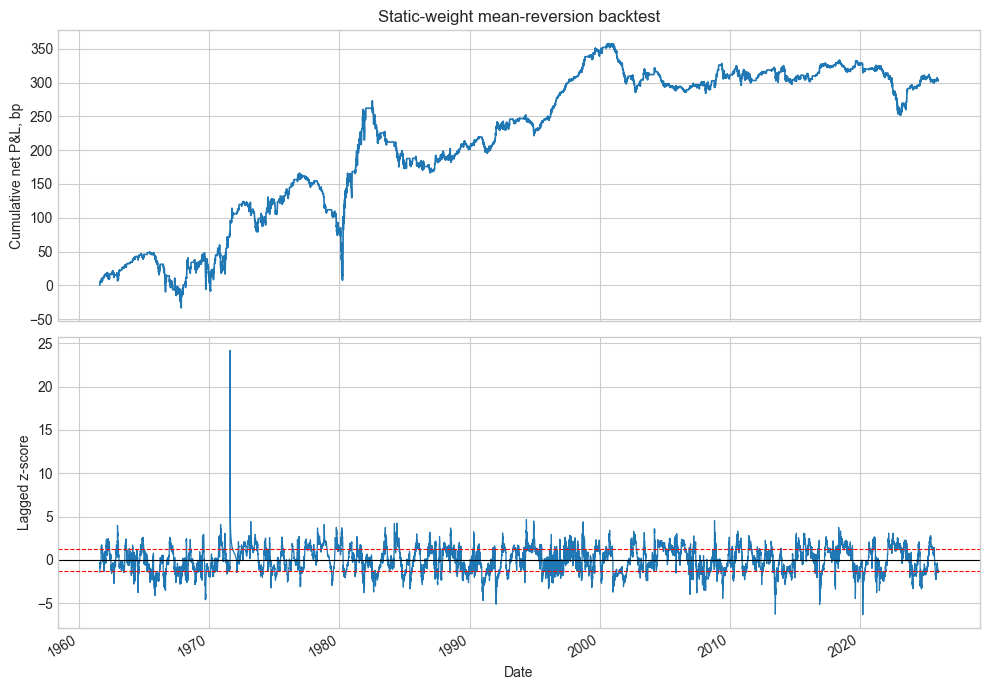

In [5]:

z_static = rolling_zscore(static_spread, lookback=126)
static_bt = backtest_mean_reversion(
    static_spread,
    z_static,
    entry_z=1.25,
    exit_z=0.25,
    cost_bp=0.02,
    max_hold_days=63,
)

display(pd.Series(performance_stats(static_bt), name="static_backtest").to_frame())

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
static_bt["cum_net_pnl"].plot(ax=axes[0], linewidth=1.2)
axes[0].set_title("Static-weight mean-reversion backtest")
axes[0].set_ylabel("Cumulative net P&L, bp")
static_bt["zscore"].plot(ax=axes[1], linewidth=0.9)
axes[1].axhline(1.25, color="red", linestyle="--", linewidth=0.8)
axes[1].axhline(-1.25, color="red", linestyle="--", linewidth=0.8)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_ylabel("Lagged z-score")
plt.tight_layout()
plt.show()



## 5. Walk-forward PCA weights

The static backtest still uses full-sample PCA loadings.  The more defensible
test re-estimates PCA weights monthly using only the previous three years of
yield changes.


,mean,std,min,max
2,0.8066,1.2355,-8.5137,17.2066
5,-1.0000,0.0000,-1.0000,-1.0000
10,0.3578,0.9859,-12.9131,7.7876


,rolling_backtest
total_pnl_bp,988.6256
ann_sharpe,0.0227
max_drawdown_bp,"-3,851.7434"
hit_rate_active,0.4812
active_days,"9,054.0000"
trades,440.0000


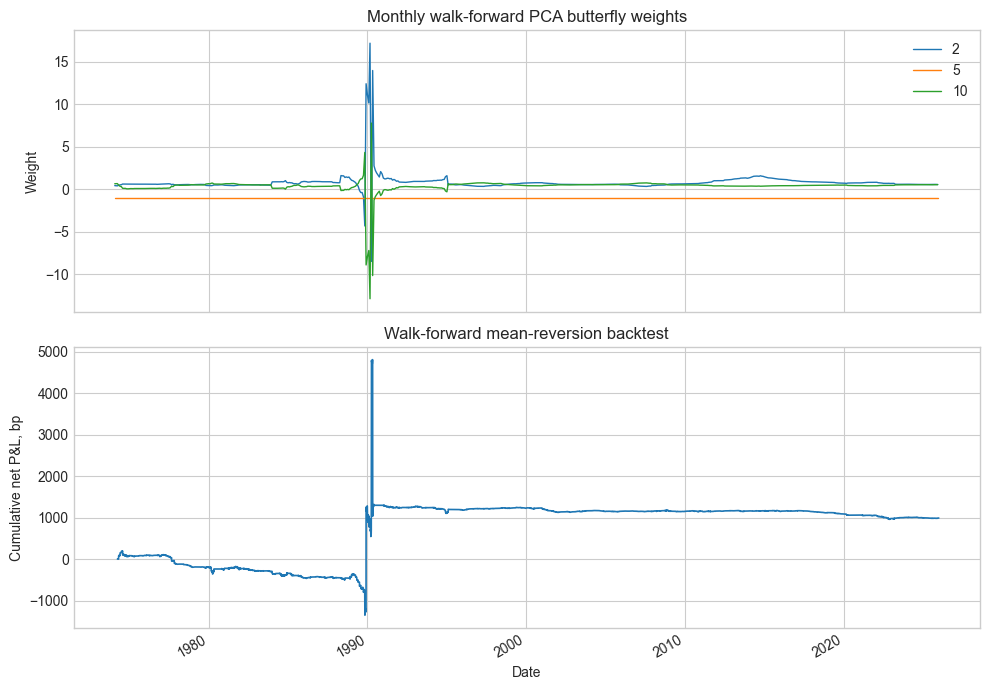

In [6]:

rolling_weights = monthly_rolling_weights(yields_bp, window=756)
rolling_spread = spread_from_weight_history(yields_bp, rolling_weights)
z_rolling = rolling_zscore(rolling_spread, lookback=126)
rolling_bt = backtest_mean_reversion(
    rolling_spread,
    z_rolling,
    entry_z=1.25,
    exit_z=0.25,
    cost_bp=0.02,
    max_hold_days=63,
)

display(rolling_weights.describe().T[["mean", "std", "min", "max"]])
display(pd.Series(performance_stats(rolling_bt), name="rolling_backtest").to_frame())

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
rolling_weights.plot(ax=axes[0], linewidth=1.0)
axes[0].set_title("Monthly walk-forward PCA butterfly weights")
axes[0].set_ylabel("Weight")
rolling_bt["cum_net_pnl"].plot(ax=axes[1], linewidth=1.2)
axes[1].set_title("Walk-forward mean-reversion backtest")
axes[1].set_ylabel("Cumulative net P&L, bp")
plt.tight_layout()
plt.show()



## 6. Regime attribution

The purpose is not to rescue the strategy by cherry-picking regimes.  It is to
show whether the residual curvature signal behaves differently across rate
environments.


In [7]:

regime_rows = []
for name, bt in {"static": static_bt, "rolling": rolling_bt}.items():
    tmp = bt.copy()
    tmp["regime"] = tmp.index.map(regime)
    for regime_name, sub in tmp.groupby("regime"):
        stats = performance_stats(sub)
        regime_rows.append({"model": name, "regime": regime_name, **stats})

regime_table = pd.DataFrame(regime_rows).set_index(["model", "regime"])
display(regime_table.round(3))


total_pnl_bp  ann_sharpe  max_drawdown_bp  hit_rate_active  \
model   regime                                                                  
static  COVID/QE       -12.6510     -0.4420         -21.3980           0.4750   
        Hiking         -21.6490     -0.3930         -62.6310           0.4690   
        Pre-COVID      326.8010      0.2340        -158.3710           0.5050   
        Recent          10.8530      0.5080         -12.9210           0.5140   
rolling COVID/QE       -33.7050     -1.1250         -41.8210           0.4410   
        Hiking         -48.3950     -0.7660         -98.3920           0.4690   
        Pre-COVID    1,087.1790      0.0270      -3,774.0370           0.4830   
        Recent         -16.4540     -0.7300         -28.4570           0.4770   

                   active_days  trades  
model   regime                          
static  COVID/QE           366      14  
        Hiking             358      21  
        Pre-COVID         9592     569  
        Recent             418      15  
rolling COVID/QE           306      17  
        Hiking             377      17  
        Pre-COVID         7984     393  
        Recent             384      16


## 7. Implementation gap: fixed maturity vs actual bonds

The GSW signal assumes clean fixed-maturity yields.  A rates desk has to express
that view in real securities.  The next block picks nearest 2Y, 5Y, and 10Y
Treasuries at monthly rebalances and compares their yield changes with GSW
fixed-maturity changes.


In [8]:

monthly_dates = pd.date_range(panel["caldt"].min(), panel["caldt"].max(), freq="BMS")
actual_dates = []
panel_dates = pd.DatetimeIndex(sorted(panel["caldt"].unique()))
for date in monthly_dates:
    loc = panel_dates.searchsorted(date)
    if loc < len(panel_dates):
        actual_dates.append(panel_dates[loc])

selected_bonds = pick_nearest_bonds(panel, targets=[2, 5, 10], rebalance_dates=actual_dates)
selection_quality = selected_bonds.groupby("target_tenor").agg(
    avg_abs_ttm_error=("ttm", lambda s: np.mean(np.abs(s - s.name)) if False else np.nan),
    median_ttm=("ttm", "median"),
    median_duration=("duration", "median"),
    n=("kytreasno", "count"),
)

# Compute maturity fit explicitly because groupby lambdas do not receive the group key.
fit_rows = []
for target, sub in selected_bonds.groupby("target_tenor"):
    fit_rows.append(
        {
            "target_tenor": target,
            "avg_abs_ttm_error": (sub["ttm"] - target).abs().mean(),
            "median_ttm": sub["ttm"].median(),
            "median_duration": sub["duration"].median(),
            "n_rebalances": len(sub),
        }
    )
selection_quality = pd.DataFrame(fit_rows).set_index("target_tenor")
display(selection_quality)


,avg_abs_ttm_error,median_ttm,median_duration,n_rebalances
target_tenor,,,,
2,0.0043,1.9959,1.9678,48
5,0.0043,4.9966,4.8153,48
10,0.1292,9.8700,8.2080,48


,mean,std,min,max
target_tenor,,,,
2,0.0038,2.6771,-31.5346,26.9482
5,0.0057,2.1930,-20.8357,17.7272
10,-0.0003,2.3010,-17.5627,13.0702


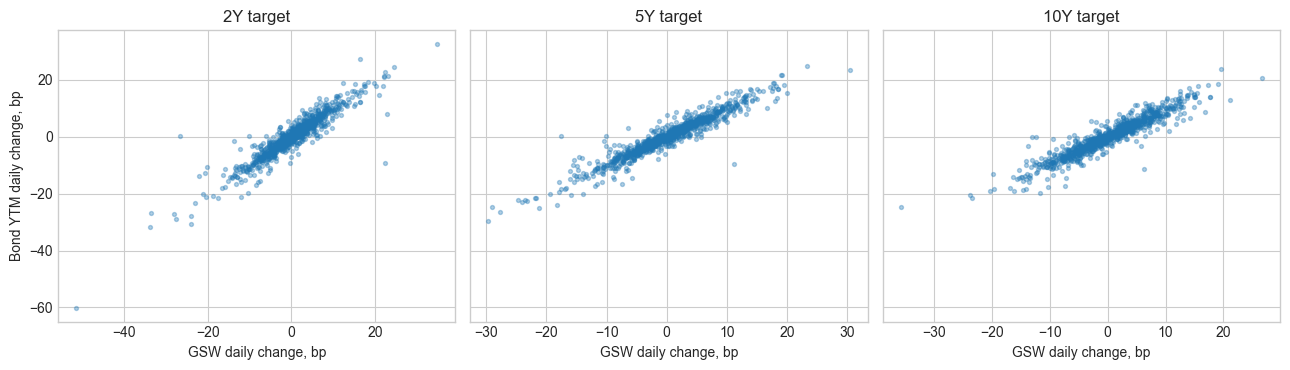

In [9]:

bond_daily_rows = []
for _, selection in selected_bonds.iterrows():
    next_dates = selected_bonds.loc[
        (selected_bonds["target_tenor"] == selection["target_tenor"])
        & (selected_bonds["rebalance_date"] > selection["rebalance_date"]),
        "rebalance_date",
    ]
    end_date = next_dates.min() if len(next_dates) else panel["caldt"].max() + pd.Timedelta(days=1)
    holding = panel[
        (panel["kytreasno"] == selection["kytreasno"])
        & (panel["caldt"] >= selection["rebalance_date"])
        & (panel["caldt"] < end_date)
    ].copy()
    holding["target_tenor"] = selection["target_tenor"]
    bond_daily_rows.append(holding)

bond_daily = pd.concat(bond_daily_rows, ignore_index=True)
bond_yields = bond_daily.pivot_table(index="caldt", columns="target_tenor", values="ytm", aggfunc="last") * 10000
bond_prices = bond_daily.pivot_table(index="caldt", columns="target_tenor", values="dirty_price", aggfunc="last")
bond_durations = bond_daily.pivot_table(index="caldt", columns="target_tenor", values="duration", aggfunc="last")

common = yields_bp[[2, 5, 10]].dropna().index.intersection(bond_yields.dropna().index)
yield_tracking = (bond_yields.loc[common, [2, 5, 10]].diff() - yields_bp.loc[common, [2, 5, 10]].diff()).dropna()
tracking_summary = yield_tracking.agg(["mean", "std", "min", "max"]).T
display(tracking_summary)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), sharey=True)
for ax, tenor in zip(axes, [2, 5, 10]):
    ax.scatter(
        yields_bp.loc[common, tenor].diff(),
        bond_yields.loc[common, tenor].diff(),
        s=8,
        alpha=0.35,
    )
    ax.set_title(f"{tenor}Y target")
    ax.set_xlabel("GSW daily change, bp")
    ax.set_ylabel("Bond YTM daily change, bp" if tenor == 2 else "")
plt.tight_layout()
plt.show()



## 8. Research conclusion

The right presentation is not "this simple z-score makes money."  The better
claim is that PCA provides a disciplined way to isolate curvature exposure, and
the research process quickly reveals where the trade gets hard: factor
instability, mean-reversion fragility, transaction costs, and the mismatch
between fixed-maturity curves and actual bond inventories.  That is the version
worth showing.


## Strategy extension: regularized RV and carry-aware momentum

The simple PCA-neutral z-score is only a starting point. This section asks two stricter questions: first, whether a regularized, gross-capped butterfly improves the mean-reversion thesis; second, whether a different signal, carry-aligned curvature momentum, is more consistent with the data.

In [10]:
from treasury_pca_butterfly import (
    RelativeValueConfig,
    curvature_momentum_carry_backtest,
    enhanced_relative_value_backtest,
    factor_exposures,
    monthly_regularized_weights,
    robust_zscore,
    rolldown_spread,
    solve_regularized_butterfly_weights,
    strategy_grid,
)

regularized_weights = solve_regularized_butterfly_weights(
    cov_fit.loadings,
    gross_cap=3.0,
    ridge=0.10,
)
regularized_exposures = factor_exposures(cov_fit.loadings, regularized_weights)
regularized_spread = compute_spread(yields_bp, regularized_weights)
regularized_carry = rolldown_spread(yields_bp, regularized_weights, horizon_days=21)
regularized_z = robust_zscore(regularized_spread, lookback=126)

rv_config = RelativeValueConfig(
    entry_z=1.50,
    exit_z=0.25,
    transaction_cost_bp=0.03,
    target_daily_vol_bp=2.50,
    max_abs_position=1.50,
)
regularized_mr_bt = enhanced_relative_value_backtest(
    regularized_spread,
    regularized_z,
    carry=regularized_carry,
    config=rv_config,
)

carry_momentum_bt = curvature_momentum_carry_backtest(
    regularized_spread,
    regularized_carry,
    momentum_lookback=63,
    carry_agreement=True,
    transaction_cost_bp=0.03,
    target_daily_vol_bp=2.50,
    max_abs_position=1.50,
)

display(regularized_weights.to_frame("regularized_weight"))
display(regularized_exposures.to_frame("factor_exposure"))
comparison = pd.DataFrame(
    {
        "regularized_mean_reversion": performance_stats(regularized_mr_bt),
        "carry_aligned_momentum": performance_stats(carry_momentum_bt),
    }
).T
display(comparison.round(4))

,regularized_weight
2,0.4047
5,-1.0000
10,0.2407


,factor_exposure
PC1,-0.1111
PC2,0.0314
PC3,0.3694


,total_pnl_bp,ann_sharpe,max_drawdown_bp,hit_rate_active,active_days,trades
regularized_mean_reversion,-372.6911,-0.3577,-454.1899,0.4925,"2,057.0000","1,705.0000"
carry_aligned_momentum,307.4696,0.1837,-125.1415,0.5108,"7,978.0000","7,345.0000"


In [11]:
grid = strategy_grid(regularized_spread, carry=regularized_carry)
display(grid.head(9).round(4))

rolling_regularized_weights = monthly_regularized_weights(
    yields_bp,
    window=756,
    gross_cap=3.0,
    ridge=0.10,
    turnover_penalty=0.05,
)
rolling_regularized_spread = spread_from_weight_history(yields_bp, rolling_regularized_weights)
rolling_regularized_carry = rolldown_spread(yields_bp, rolling_regularized_weights, horizon_days=21)
rolling_regularized_z = robust_zscore(rolling_regularized_spread, lookback=126)
rolling_regularized_mr_bt = enhanced_relative_value_backtest(
    rolling_regularized_spread,
    rolling_regularized_z,
    carry=rolling_regularized_carry,
    config=rv_config,
)

display(rolling_regularized_weights[[2, 5, 10, "PC1_exposure", "PC2_exposure", "gross"]].describe().round(4))
display(pd.Series(performance_stats(rolling_regularized_mr_bt), name="rolling_regularized_mean_reversion").to_frame())

,lookback,entry_z,cost_bp,total_pnl_bp,ann_sharpe,max_drawdown_bp,hit_rate_active,active_days,trades
24,252,2.0000,0.0100,-100.0369,-0.1343,-180.3661,0.4888,1023,852
25,252,2.0000,0.0300,-101.2150,-0.1359,-180.8628,0.4878,1023,852
26,252,2.0000,0.0500,-102.3931,-0.1375,-181.3595,0.4878,1023,852
21,252,1.5000,0.0100,-151.4189,-0.1681,-210.3501,0.4923,1678,1402
22,252,1.5000,0.0300,-153.3425,-0.1702,-211.9024,0.4923,1678,1402
23,252,1.5000,0.0500,-155.2662,-0.1723,-213.4546,0.4923,1678,1402
18,252,1.0000,0.0100,-195.6135,-0.1774,-267.7852,0.4980,2693,2325
19,252,1.0000,0.0300,-198.8190,-0.1803,-270.3609,0.4980,2693,2325
20,252,1.0000,0.0500,-202.0244,-0.1833,-272.9366,0.4980,2693,2325


,2,5,10,PC1_exposure,PC2_exposure,gross
count,623.0000,623.0000,623.0000,623.0000,623.0000,623.0000
mean,0.3993,-1.0000,0.2363,-0.0873,0.0718,1.6356
std,0.0859,0.0000,0.0664,0.0206,0.0602,0.1110
min,0.1811,-1.0000,0.0467,-0.1305,-0.0731,1.3751
25%,0.3484,-1.0000,0.2069,-0.1008,0.0440,1.5868
50%,0.4216,-1.0000,0.2333,-0.0891,0.0698,1.6332
75%,0.4660,-1.0000,0.2659,-0.0731,0.1107,1.7063
max,0.5373,-1.0000,0.4279,-0.0329,0.2163,1.8607


,rolling_regularized_mean_reversion
total_pnl_bp,-449.2806
ann_sharpe,-0.4985
max_drawdown_bp,-493.2492
hit_rate_active,0.4965
active_days,"2,117.0000"
trades,"1,916.0000"


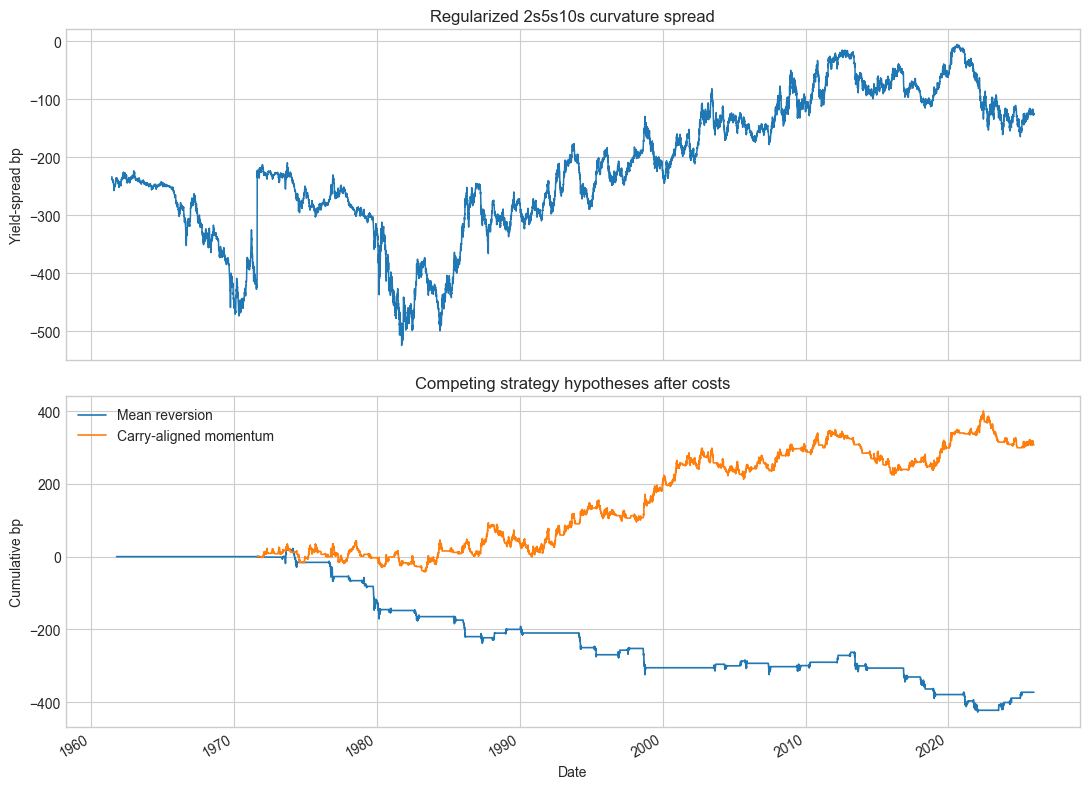

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
regularized_spread.plot(ax=axes[0], linewidth=1.1, color="tab:blue")
axes[0].set_title("Regularized 2s5s10s curvature spread")
axes[0].set_ylabel("Yield-spread bp")
regularized_mr_bt["cum_net_pnl"].plot(ax=axes[1], label="Mean reversion", linewidth=1.2)
carry_momentum_bt["cum_net_pnl"].plot(ax=axes[1], label="Carry-aligned momentum", linewidth=1.2)
axes[1].set_title("Competing strategy hypotheses after costs")
axes[1].set_ylabel("Cumulative bp")
axes[1].legend()
plt.tight_layout()
plt.show()

### Strategy interpretation

The stricter evidence rejects the naive mean-reversion story: regularized, carry-gated mean reversion loses money after costs. The more promising branch is carry-aligned curvature momentum. Its Sharpe is still modest, but it has lower drawdown than the fading rule and is more consistent with the weak stationarity diagnostics.

## Robustness and Anti-Overfit Checks

The stricter question is whether the apparent curvature results survive validation designs that respect serial dependence, overlapping holding periods, and strategy selection. The checks below use purged/embargoed CPCV folds with a max-holding-period purge, nested blocked selection for the mean-reversion grid, a block-bootstrap null for the factor residual, and a full-curve covariance random-walk Monte Carlo. The goal is not to rescue every signal; it is to distinguish economically motivated robustness from path fitting.

In [13]:
from treasury_pca_butterfly import (
    PurgedSplitConfig,
    covariance_random_walk_strategy_null,
    factor_residual_block_bootstrap_null,
    strategy_family_cpcv_table,
    summarize_strategy_validation,
    walk_forward_strategy_selection,
)

treasury_split_config = PurgedSplitConfig(
    n_groups=8,
    n_test_groups=2,
    label_horizon=42,
    embargo=5,
)

rv_validation_configs = [
    RelativeValueConfig(
        entry_z=entry,
        exit_z=0.25,
        lookback=lookback,
        max_hold_days=42,
        transaction_cost_bp=cost,
        target_daily_vol_bp=2.50,
        max_abs_position=1.50,
        carry_tolerance_bp=0.05,
    )
    for lookback in (63, 126, 252)
    for entry in (1.0, 1.5, 2.0)
    for cost in (0.01, 0.03, 0.05)
]

rv_cpcv = strategy_family_cpcv_table(
    regularized_spread,
    regularized_carry,
    rv_validation_configs,
    momentum_lookbacks=(21, 63, 126),
    split_config=treasury_split_config,
)
rv_cpcv_summary = summarize_strategy_validation(rv_cpcv)

display(rv_cpcv_summary.head(15).round(4))


folds  \
strategy_family            config_id lookback entry_z transaction_cost_bp          
carry_aligned_momentum     21        21       NaN     0.0300                  28   
                           63        63       NaN     0.0300                  28   
                           126       126      NaN     0.0300                  28   
carry_gated_mean_reversion 24        252      2.0000  0.0100                  28   
                           25        252      2.0000  0.0300                  28   
                           26        252      2.0000  0.0500                  28   
                           21        252      1.5000  0.0100                  28   
                           22        252      1.5000  0.0300                  28   
                           23        252      1.5000  0.0500                  28   
                           18        252      1.0000  0.0100                  28   
                           19        252      1.0000  0.0300                  28   
                           20        252      1.0000  0.0500                  28   
                           15        126      2.0000  0.0100                  28   
                           16        126      2.0000  0.0300                  28   
                           17        126      2.0000  0.0500                  28   

                                                                           mean_test_n  \
strategy_family            config_id lookback entry_z transaction_cost_bp                
carry_aligned_momentum     21        21       NaN     0.0300                3,390.2500   
                           63        63       NaN     0.0300                3,390.2500   
                           126       126      NaN     0.0300                3,390.2500   
carry_gated_mean_reversion 24        252      2.0000  0.0100                3,390.2500   
                           25        252      2.0000  0.0300                3,390.2500   
                           26        252      2.0000  0.0500                3,390.2500   
                           21        252      1.5000  0.0100                3,390.2500   
                           22        252      1.5000  0.0300                3,390.2500   
                           23        252      1.5000  0.0500                3,390.2500   
                           18        252      1.0000  0.0100                3,390.2500   
                           19        252      1.0000  0.0300                3,390.2500   
                           20        252      1.0000  0.0500                3,390.2500   
                           15        126      2.0000  0.0100                3,390.2500   
                           16        126      2.0000  0.0300                3,390.2500   
                           17        126      2.0000  0.0500                3,390.2500   

                                                                           mean_total_pnl_bp  \
strategy_family            config_id lookback entry_z transaction_cost_bp                      
carry_aligned_momentum     21        21       NaN     0.0300                         81.3362   
                           63        63       NaN     0.0300                         76.8674   
                           126       126      NaN     0.0300                         -3.3284   
carry_gated_mean_reversion 24        252      2.0000  0.0100                        -24.2439   
                           25        252      2.0000  0.0300                        -24.5261   
                           26        252      2.0000  0.0500                        -24.8083   
                           21        252      1.5000  0.0100                        -40.6162   
                           22        252      1.5000  0.0300                        -41.0694   
                           23        252      1.5000  0.0500                        -41.5225   
                           18        252      1.0000  0.010

In [14]:
rv_walk_forward_selection = walk_forward_strategy_selection(
    regularized_spread,
    regularized_carry,
    rv_validation_configs,
    PurgedSplitConfig(n_groups=6, n_test_groups=1, label_horizon=42, embargo=5),
)

display(rv_walk_forward_selection.round(4))


,fold,selected_config_id,selected_lookback,selected_entry_z,train_objective,test_total_pnl_bp,test_ann_sharpe,test_max_drawdown_bp,test_hit_rate_active,test_active_days,test_trades
0,0,24,252,2.0000,0.0512,-118.9959,-0.6104,-179.4367,0.4611,373,239
1,1,24,252,2.0000,-0.1280,-20.5902,-0.2798,-31.4548,0.4444,126,129
2,2,24,252,2.0000,-0.1605,0.0451,0.0008,-24.0274,0.5476,42,43
3,3,18,252,1.0000,-0.2000,-35.7305,-0.2466,-73.5516,0.4815,297,238
4,4,24,252,2.0000,-0.1184,-30.5493,-0.2945,-48.8455,0.5079,126,120
5,5,21,252,1.5000,-0.2066,-16.6526,-0.1265,-61.1041,0.5094,318,288


In [15]:
rv_block_null = factor_residual_block_bootstrap_null(
    regularized_spread,
    regularized_carry,
    strategy="momentum",
    momentum_lookback=63,
    block_size=21,
    n_sims=1000,
    seed=17,
)
rv_covariance_null = covariance_random_walk_strategy_null(
    yields_bp,
    regularized_weights,
    strategy="momentum",
    momentum_lookback=63,
    n_sims=500,
    seed=19,
)

treasury_null_summary = pd.DataFrame(
    {
        "block_residual_null": {
            "observed_total_pnl_bp": rv_block_null["observed_total_pnl_bp"].iloc[0],
            "observed_ann_sharpe": rv_block_null["observed_ann_sharpe"].iloc[0],
            "pvalue_total_pnl": rv_block_null["pvalue_total_pnl"].iloc[0],
            "pvalue_ann_sharpe": rv_block_null["pvalue_ann_sharpe"].iloc[0],
            "null_total_pnl_5pct": rv_block_null["total_pnl_bp"].quantile(0.05),
            "null_total_pnl_50pct": rv_block_null["total_pnl_bp"].quantile(0.50),
            "null_total_pnl_95pct": rv_block_null["total_pnl_bp"].quantile(0.95),
        },
        "full_curve_covariance_null": {
            "observed_total_pnl_bp": rv_covariance_null["observed_total_pnl_bp"].iloc[0],
            "observed_ann_sharpe": rv_covariance_null["observed_ann_sharpe"].iloc[0],
            "pvalue_total_pnl": rv_covariance_null["pvalue_total_pnl"].iloc[0],
            "pvalue_ann_sharpe": rv_covariance_null["pvalue_ann_sharpe"].iloc[0],
            "null_total_pnl_5pct": rv_covariance_null["total_pnl_bp"].quantile(0.05),
            "null_total_pnl_50pct": rv_covariance_null["total_pnl_bp"].quantile(0.50),
            "null_total_pnl_95pct": rv_covariance_null["total_pnl_bp"].quantile(0.95),
        },
    }
)

display(treasury_null_summary.round(4))


,block_residual_null,full_curve_covariance_null
observed_total_pnl_bp,307.4696,274.3035
observed_ann_sharpe,0.1837,0.2128
pvalue_total_pnl,0.1130,0.0640
pvalue_ann_sharpe,0.1160,0.0800
null_total_pnl_5pct,-333.3904,-326.2749
null_total_pnl_50pct,24.4052,-22.7654
null_total_pnl_95pct,390.7555,301.8182


In [16]:
treasury_sensitivity_rows = []
for method in ("covariance", "correlation"):
    for pca_window in (504, 756, 1008):
        window_fit = fit_pca(yields_bp.iloc[-pca_window:], method=method)
        if not {2, 5, 10}.issubset(set(window_fit.loadings.index)):
            continue
        exact_w = solve_butterfly_weights(window_fit.loadings)
        reg_w = solve_regularized_butterfly_weights(window_fit.loadings, gross_cap=3.0, ridge=0.10)
        for hedge_type, hedge_w in ("exact", exact_w), ("regularized", reg_w):
            exposures = factor_exposures(window_fit.loadings, hedge_w)
            treasury_sensitivity_rows.append(
                {
                    "method": method,
                    "pca_window_days": pca_window,
                    "hedge_type": hedge_type,
                    "gross": hedge_w.abs().sum(),
                    "pc1_abs_exposure": abs(exposures.get("PC1", np.nan)),
                    "pc2_abs_exposure": abs(exposures.get("PC2", np.nan)),
                    "pc3_exposure": exposures.get("PC3", np.nan),
                }
            )

treasury_hedge_sensitivity = pd.DataFrame(treasury_sensitivity_rows)
display(treasury_hedge_sensitivity.round(4))

momentum_sensitivity_rows = []
for lookback in (21, 63, 126):
    for carry_gate in (True, False):
        for cost in (0.01, 0.03, 0.05):
            bt = curvature_momentum_carry_backtest(
                regularized_spread,
                regularized_carry,
                momentum_lookback=lookback,
                carry_agreement=carry_gate,
                transaction_cost_bp=cost,
            )
            momentum_sensitivity_rows.append(
                {
                    "momentum_lookback": lookback,
                    "carry_gate": carry_gate,
                    "transaction_cost_bp": cost,
                    **performance_stats(bt),
                }
            )

momentum_sensitivity = pd.DataFrame(momentum_sensitivity_rows)
display(
    momentum_sensitivity.pivot_table(
        index=["momentum_lookback", "carry_gate"],
        columns="transaction_cost_bp",
        values="ann_sharpe",
    ).round(3)
)

regime_table = carry_momentum_bt.copy()
regime_table["regime"] = [regime(date) for date in regime_table.index]
regime_summary = regime_table.groupby("regime")["net_pnl"].agg(["count", "sum", "mean", "std"])
regime_summary["ann_sharpe"] = regime_summary["mean"] / regime_summary["std"] * np.sqrt(252)
display(regime_summary.round(4))


,method,pca_window_days,hedge_type,gross,pc1_abs_exposure,pc2_abs_exposure,pc3_exposure
0,covariance,504,exact,2.0834,0.0000,0.0000,0.0522
1,covariance,504,regularized,1.6288,0.0837,0.0747,0.0778
2,covariance,756,exact,2.0847,0.0000,0.0000,0.0034
3,covariance,756,regularized,1.6169,0.0898,0.0639,-0.0314
4,covariance,1008,exact,2.0852,0.0000,0.0000,0.0254
5,covariance,1008,regularized,1.6306,0.0875,0.0692,0.0470
6,correlation,504,exact,2.0513,0.0000,0.0000,0.0399
7,correlation,504,regularized,1.5947,0.0813,0.0721,0.0639
8,correlation,756,exact,2.0561,0.0000,0.0000,0.0058
9,correlation,756,regularized,1.6017,0.0807,0.0731,-0.0238


transaction_cost_bp           0.0100  0.0300  0.0500
momentum_lookback carry_gate                        
21                False       0.3530  0.3290  0.3050
                  True        0.2250  0.2050  0.1850
63                False       0.3250  0.3110  0.2960
                  True        0.1970  0.1840  0.1700
126               False       0.0290  0.0170  0.0060
                  True        0.0040 -0.0080 -0.0200

,count,sum,mean,std,ann_sharpe
regime,,,,,
COVID/QE,502,37.6595,0.0750,1.7323,0.6874
Hiking,499,-12.5804,-0.0252,2.0086,-0.1993
Pre-COVID,12064,299.1568,0.0248,1.9747,0.1993
Recent,496,-16.7663,-0.0338,1.7312,-0.3100


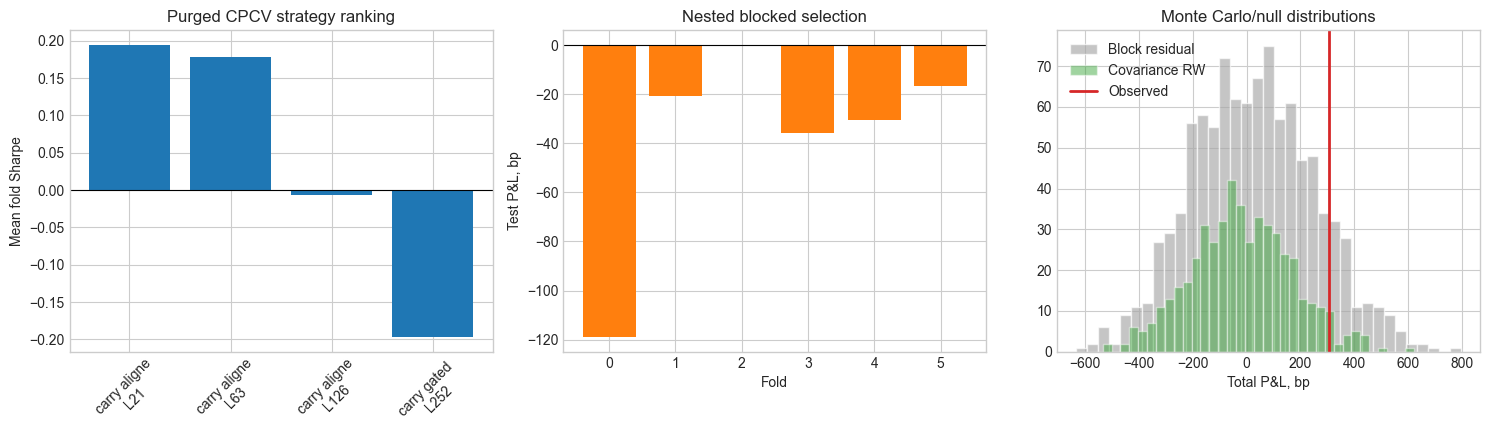

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

plot_cpcv = rv_cpcv_summary.reset_index().head(10)
labels = [f"{row.strategy_family.replace('_', ' ')[:12]}\nL{int(row.lookback)}" for _, row in plot_cpcv.iterrows()]
axes[0].bar(labels, plot_cpcv["mean_ann_sharpe"], color="tab:blue")
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_title("Purged CPCV strategy ranking")
axes[0].set_ylabel("Mean fold Sharpe")
axes[0].tick_params(axis="x", rotation=45)

axes[1].bar(rv_walk_forward_selection["fold"].astype(str), rv_walk_forward_selection["test_total_pnl_bp"], color="tab:orange")
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("Nested blocked selection")
axes[1].set_xlabel("Fold")
axes[1].set_ylabel("Test P&L, bp")

axes[2].hist(rv_block_null["total_pnl_bp"], bins=35, alpha=0.65, label="Block residual", color="0.65", edgecolor="white")
axes[2].hist(rv_covariance_null["total_pnl_bp"], bins=35, alpha=0.45, label="Covariance RW", color="tab:green", edgecolor="white")
axes[2].axvline(treasury_null_summary.loc["observed_total_pnl_bp", "block_residual_null"], color="tab:red", linewidth=2, label="Observed")
axes[2].set_title("Monte Carlo/null distributions")
axes[2].set_xlabel("Total P&L, bp")
axes[2].legend()

plt.tight_layout()
fig.savefig(PROJECT_ROOT / "paper" / "figures" / "treasury_robustness_summary.pdf", bbox_inches="tight")
plt.show()
